# Online Retail Analysis

### Proyecto Final de Codecademy Data Scientist: Analytics

## Autor: Agustín Pluda

# Índice de Contenidos
- [Descripción](#descripción)
- [Objetivo](#objetivo)
- [1. Importación de Librerias](#1-importacion-de-librerias)
- [2. Carga del dataset](#2-carga-del-dataset)
- [3. Exploración Inicial](#3-exploración-inicial)
  - [3.1 Limpieza de Datos](#31-limpieza-de-datos)
  - [3.2 Formateo de Datos](#32-formateo-de-datos)
  - [3.3 Creación de Dataframes para el análisis](#33-creación-de-dataframes-para-el-análisis)
  - [3.4 Guardado de Dataframes a CSV](#34-guardado-de-dataframes-a-csv)
- [4. Análisis Exploratorio de Datos (EDA)](#4-analisis-exploratorio-de-datos-eda)
  - [4.1 Articulos](#41-articulos)
  - [4.2 Facturas y Clientes](#42-facturas-y-clientes)
  - [4.3 Fechas y Horas](#43-fechas-y-horas)
  - [4.4 Paises](#44-paises)
  - [4.5 Extras](#45-extras)
- [5. Hallazgos Claves](#5-hallazgos-claves)
- [6. Conclusiones](#6-conclusiones)

## Descripción
Este proyecto se trata del final de mi curso de "Data Scientist: Analytics" de Codecademy, en el cual, a través de un análisis de datos de un dataset a elección propia, demostrando gran parte de lo que he aprendido en mi tiempo de cursado.

El dataset que elegí fue "online_retail_II.csv" (https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci), que se trata de todas las transacciones realizadas por una empresa de venta minorista en línea, registrada en el Reino Unido y sin establecimiento físico, entre el 1 de diciembre de 2009 y el 9 de diciembre de 2011. La empresa se dedica principalmente a la venta de artículos de regalo únicos para cualquier ocasión. Muchos de sus clientes son mayoristas.

Elegí este dataset porque contiene más de un millón de filas de datos, en las cuales hay datos faltantes, inconsistentes y formatos incorrectos, etc.

## Objetivo
El objetivo este proyecto es el proceso completo de análisis del dataset, que se trata de:
- Carga del dataset, 
- Exploración Inicial de los datos, 
- Curado de los datos (limpieza y formateo), 
- Análisis exploratorio de datos (EDA) con preguntas de negocio, 
- Hallazgos claves, 
- Conclusión.

# 1. Importación de Librerias

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter
from scipy.stats import mannwhitneyu, spearmanr

%matplotlib inline

## 1.1 Sistema visual

Todos los gráficos del análisis comparten una misma paleta, tipografía y estructura, definidas
una sola vez en la celda siguiente. Las reglas de color son las siguentes:

* **Azul** para la serie principal: un único color para todas las barras de una misma medida.
* **Naranja** solo como acento, para destacar un elemento puntual (el pico, el país propio).
* **Rojo** reservado al estado "factura cancelada", y nunca reutilizado como color de serie.
* **Gris** para el contexto y los datos de-enfatizados.

In [43]:
# --- Sistema visual del proyecto ---

AZUL    = "#2a78d6"   # serie principal
NARANJA = "#eb6834"   # acento: destacar un elemento puntual
ROJO    = "#e34948"   # reservado al estado "cancelada"
GRIS    = "#9a9a94"   # contexto / datos de-enfatizados
TINTA   = "#1a1a19"   # texto principal
TINTA_2 = "#52514e"   # subtítulos y etiquetas de eje
LINEA   = "#e4e3df"   # grilla y ejes

MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 10.5, "axes.titlesize": 13, "axes.labelsize": 10.5,
    "axes.labelcolor": TINTA_2, "text.color": TINTA,
    "xtick.color": TINTA_2, "ytick.color": TINTA_2,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.edgecolor": LINEA, "grid.color": LINEA, "grid.linewidth": 0.8,
    "axes.grid": False, "axes.axisbelow": True,
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 200,
})


def num(x, dec=0):
    """Formatea un número al estilo español: 1.234.567,89"""
    return f"{x:,.{dec}f}".replace(",", "\u00a0").replace(".", ",").replace("\u00a0", ".")


def libras(x, dec=0):
    return "£" + num(x, dec)


def pct(x, dec=1):
    return num(x, dec) + "%"


def estilo(ax, eje_valores="x"):
    """Saca el marco y deja una grilla fina solo sobre el eje de magnitud."""
    sns.despine(ax=ax, left=(eje_valores == "x"))
    ax.grid(axis=eje_valores, linewidth=0.8, color=LINEA)
    ax.tick_params(length=0)
    return ax


def titulo(ax, texto, subtitulo=None):
    """Título alineado a la izquierda con un subtítulo gris que resume el hallazgo."""
    if subtitulo:
        ax.set_title(subtitulo, loc="left", fontsize=10, color=TINTA_2, pad=8, linespacing=1.4)
        desplazamiento = 10 + 13.5 * (subtitulo.count("\n") + 1)
    else:
        ax.set_title("")
        desplazamiento = 10
    ax.annotate(texto, xy=(0, 1), xycoords="axes fraction",
                xytext=(0, desplazamiento), textcoords="offset points",
                fontsize=13, fontweight="bold", color=TINTA, ha="left", va="bottom")


def formato(ax, eje="x", moneda=False, dec=0):
    """Separador de miles (y símbolo de libra) en el eje indicado."""
    f = FuncFormatter(lambda v, _: (libras if moneda else num)(v, dec))
    (ax.xaxis if eje == "x" else ax.yaxis).set_major_formatter(f)


def etiquetar_barras(ax, fmt=num, pad=4):
    """Valor al final de cada barra, sin recuadro."""
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt=fmt, padding=pad, fontsize=9, color=TINTA_2)


def guardar(fig, nombre):
    fig.savefig(f"images/{nombre}.png", dpi=200, bbox_inches="tight")

# 2. Carga del dataset

Primero cargamos el dataset y inspeccionamos su estructura.

In [44]:
df = pd.read_csv("data/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 3. Exploración Inicial
Vamos a entender la estructura de los datos antes de realizar cualquier análisis.

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


In [46]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [47]:
df.shape

(1067371, 8)

## 3.1 Limpieza de Datos

### 3.1.1 Datos Nulos

In [48]:
print(df.isnull().sum())
print("")
print("Valores Nulos Totales:", df.isnull().sum().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Valores Nulos Totales: 247389


Tenemos 247.389 celdas vacías de datos, los cuales 
- 243.007 corresponden a IDs de clientes y 
- 4.382 corresponden a descripción de producto.

En este caso, me procederé a borrar las filas de datos que no tengan descripción, si lo dejo puede ser problemático para realizar los gráficos y análisis posteriores. En el caso de los IDs de cliente, no tendré problema de dejarlos, al fin al cabo mi análisis no estará enfocados en ellos.


In [49]:
df.dropna(subset=["Description"], inplace=True)

print("Valores nulos después de la limpieza:")
print(df.isnull().sum())

Valores nulos después de la limpieza:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    238625
Country             0
dtype: int64


### 3.1.2 Datos Duplicados

In [50]:
print("Filas Duplicadas:", df.duplicated().sum())

Filas Duplicadas: 34228


Este dataset contiene 34.228 filas duplicadas, en este caso las vamos a extraer porque afectaría
nuestro posterior análisis, dando visualizaciones erróneas de lo que realmente contiene el set.

In [51]:
df.drop_duplicates(inplace=True)

print("Filas duplicadas después de la limpieza:", df.duplicated().sum())

Filas duplicadas después de la limpieza: 0


### 3.1.3 Registros no comerciales
El atributo StockCode identifica cada producto del dataset. La mayoría de los códigos siguen el formato de cinco dígitos, aunque también existen productos con variantes identificadas mediante letras, por ejemplo 85049A y 85049B. Por este motivo, no se consideraron inválidos los códigos únicamente por contener letras.

Para identificar registros que no correspondieran al formato habitual de los productos, se utilizó una expresión regular que detecta códigos formados por cinco dígitos, opcionalmente seguidos de letras:


In [52]:
# Identificar StockCode que no siguen el formato habitual de productos
special_codes = df[~df["StockCode"].str.match(r"^\d{5}[A-Za-z]*$", na=False)]

print(special_codes["StockCode"].value_counts())

StockCode
POST            2079
DOT             1423
M               1387
C2               274
D                173
S                101
BANK CHARGES     100
ADJUST            67
AMAZONFEE         36
DCGS0058          30
gift_0001_20      27
gift_0001_30      24
DCGSSGIRL         24
DCGSSBOY          22
PADS              19
CRUK              16
TEST001           15
DCGS0076          14
DCGS0003          14
gift_0001_10      14
gift_0001_50       6
DCGS0069           6
B                  6
m                  5
gift_0001_40       5
DCGS0004           4
DCGS0068           3
DCGS0072           3
ADJUST2            3
gift_0001_80       2
DCGS0066N          2
DCGS0070           2
SP1002             2
DCGS0044           1
TEST002            1
DCGS0075           1
DCGS0041           1
gift_0001_70       1
DCGS0037           1
47503J             1
DCGS0062           1
DCGS0073           1
DCGS0067           1
Name: count, dtype: int64


A partir de esta revisión, se identificaron dos grupos:

**Códigos que representan productos o servicios comerciales y se conservarán:**

- DCGS...: corresponden a productos reales, como DCGS0003 (BOXED GLASS ASHTRAY) y DCGSSGIRL (GIRLS PARTY BAG).
- gift_0001_XX: corresponden a gift vouchers de distintos valores.
- SP1002: corresponde al producto KID'S CHALKBOARD/EASEL.

Estos códigos **no se eliminarán**, ya que representan artículos o servicios comercializados.

**Códigos que corresponden a registros administrativos, cargos o registros no relacionados con la venta de productos y serán excluidos del análisis de artículos:**

- ADJUST y ADJUST2: ajustes administrativos.
- AMAZONFEE: cargos de Amazon.
- BANK CHARGES: cargos bancarios.
- B: ajustes de deuda.
- C2, D y S: registros especiales.
- CRUK: registro especial.
- M y m: registros manuales.
- PADS: registro especial.
- POST: gastos de envío (POSTAGE).
- DOT: gastos de envío de Dotcom (DOTCOM POSTAGE).
- TEST001 y TEST002: registros de prueba.

Para evitar eliminar esta información del DataFrame original, se creó un nuevo DataFrame destinado específicamente al análisis de productos:

In [53]:
# Códigos correspondientes a registros no comerciales 
non_product_codes = [ "ADJUST", "ADJUST2", "AMAZONFEE", "BANK CHARGES", "B", "C2", "CRUK", 
                     "D", "M", "m", "PADS", "POST", "S", "TEST001", "TEST002", "DOT" ] 

# DataFrame destinado al análisis de productos 
df_products = df[~df["StockCode"].isin(non_product_codes)].copy()

print("Registros originales:", len(df))
print("Registros para análisis de productos:", len(df_products))
print("Registros excluidos:", len(df) - len(df_products))

Registros originales: 1028761
Registros para análisis de productos: 1023056
Registros excluidos: 5705


De esta manera, el DataFrame original conserva todos los registros del dataset, mientras que df_products permite realizar análisis centrados exclusivamente en artículos y servicios comercializados, evitando que cargos, ajustes, gastos de envío y registros administrativos distorsionen los resultados.

### 3.1.4 Valores inconsistentes en Quantity y Price

In [54]:
# Cantidades menores o iguales a cero
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

# Precios menores o iguales a cero
print("Price <= 0:", (df["Price"] <= 0).sum())

Quantity <= 0: 19863
Price <= 0: 1744


In [55]:
# Identificar facturas canceladas
canceled = df["Invoice"].str.upper().str.startswith("C")

print("Quantity <= 0 en facturas canceladas:",
      ((df["Quantity"] <= 0) & canceled).sum())

print("Quantity <= 0 en facturas no canceladas:",
      ((df["Quantity"] <= 0) & ~canceled).sum())

Quantity <= 0 en facturas canceladas: 19103
Quantity <= 0 en facturas no canceladas: 760


In [56]:
df[(df["Quantity"] <= 0) & ~canceled][["Invoice", "StockCode", "Description", "Quantity", "Price"]].head(20)

,Invoice,StockCode,Description,Quantity,Price
263,489464,21733,85123a mixed,-96,0.0
283,489463,71477,short,-240,0.0
284,489467,85123A,21733 mixed,-192,0.0
3162,489660,35956,lost,-1043,0.0
3168,489663,35605A,damages,-117,0.0
4538,489820,21133,invcd as 84879?,-720,0.0
6556,489899,79323GR,sold as gold,-954,0.0
6911,490007,84347,21494,-720,0.0
9308,490130,21493,lost?,-600,0.0
17427,490765,21450,damaged,-31,0.0


In [57]:
df[df["Price"] <= 0][["Invoice", "StockCode", "Description", "Quantity", "Price"]].head(20)

,Invoice,StockCode,Description,Quantity,Price
263,489464,21733,85123a mixed,-96,0.0
283,489463,71477,short,-240,0.0
284,489467,85123A,21733 mixed,-192,0.0
3162,489660,35956,lost,-1043,0.0
3168,489663,35605A,damages,-117,0.0
4538,489820,21133,invcd as 84879?,-720,0.0
4674,489825,22076,6 RIBBONS EMPIRE,12,0.0
5904,489861,DOT,DOTCOM POSTAGE,1,0.0
6556,489899,79323GR,sold as gold,-954,0.0
6781,489998,48185,DOOR MAT FAIRY CAKE,2,0.0


Se analizaron los valores no positivos de las variables Quantity y Price, ya que ambos atributos son fundamentales para calcular el valor de las transacciones y realizar posteriormente el análisis de ventas.

En primer lugar, se identificaron 19.863 registros con Quantity <= 0. Al comparar estos registros con las facturas canceladas, se observó que 19.103 corresponden a facturas cuyo Invoice comienza con C, mientras que 760 registros presentan cantidades no positivas sin estar asociados a una factura cancelada.

Los registros que no corresponden a facturas canceladas contienen descripciones como "lost", "damaged", "wet", "bad quality", "missing", "smashed" y "discoloured", lo que indica que corresponden principalmente a ajustes o incidencias relacionadas con el inventario y no a ventas normales.

También se identificaron 1.744 registros con Price <= 0. Dentro de estos registros existen tanto cantidades negativas como transacciones con cantidades positivas y precio igual a cero. Debido a que un precio no positivo no representa una venta con valor monetario para el análisis de ingresos, estos registros no serán utilizados en el análisis de ventas.

Por lo tanto, se conservará el DataFrame original para mantener la información completa del dataset, mientras que para el análisis de ventas se creará un nuevo DataFrame que contenga únicamente transacciones con cantidades y precios positivos:

In [58]:
# DataFrame para el análisis de ventas 
df_sales = df_products[(df_products["Quantity"] > 0) & (df_products["Price"] > 0)].copy()

print("Registros en df_products:", len(df_products)) 
print("Registros en df_sales:", len(df_sales)) 
print("Registros excluidos:", len(df_products) - len(df_sales))

Registros en df_products: 1023056
Registros en df_sales: 1003417
Registros excluidos: 19639


De esta manera, los registros de cancelaciones, devoluciones, ajustes de inventario y transacciones sin valor monetario no se eliminan del dataset original, pero tampoco interfieren en los análisis posteriores relacionados con cantidades vendidas, precios, ingresos y productos más vendidos.

## 3.2 Formateo de Datos

### 3.2.1 Renombramiento de columnas

Para facilitar el trabajo con las variables durante el análisis, se renombraron todas las columnas utilizando el formato snake_case.

Además, la columna InvoiceDate fue renombrada como invoice_datetime, ya que a que contiene tanto la fecha como la hora en la que se generó cada transacción, por lo que el nombre original no representa completamente su contenido.

In [59]:
df.rename(columns={"Invoice": "invoice", 
                   "StockCode": "stock_code", 
                   "Description": "description", 
                   "Quantity": "quantity", 
                   "InvoiceDate": "invoice_datetime", 
                   "Price": "unit_price", 
                   "Customer ID": "customer_id", 
                   "Country": "country"
                   }, inplace=True)

### 3.2.2 Corrección de tipos de datos

Se revisaron los tipos de datos de las columnas para asegurar que cada variable tenga un formato adecuado para las operaciones que se realizarán posteriormente.

La columna customer_id fue convertida a tipo string, debido a que representa un identificador de cliente y no una variable numérica sobre la cual se realizarán operaciones matemáticas.

Por otro lado, invoice_datetime fue convertida al formato datetime, permitiendo realizar operaciones relacionadas con fechas y horas, como extraer años, meses, días y horas.

In [60]:
# customer_id es un identificador, no una magnitud: se pasa primero a entero
# para no arrastrar el ".0" del float original, y recién después a texto.
df = df.astype({"customer_id": "Int64"}).astype({"customer_id": "string"})

df["invoice_datetime"] = pd.to_datetime(df["invoice_datetime"])

df.info()

<class 'pandas.DataFrame'>
Index: 1028761 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   invoice           1028761 non-null  str           
 1   stock_code        1028761 non-null  str           
 2   description       1028761 non-null  str           
 3   quantity          1028761 non-null  int64         
 4   invoice_datetime  1028761 non-null  datetime64[us]
 5   unit_price        1028761 non-null  float64       
 6   customer_id       797885 non-null   string        
 7   country           1028761 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(4), string(1)
memory usage: 70.6 MB


### 3.2.3 Agregado de columnas

Finalmente, se agregaron nuevas variables derivadas de las columnas existentes con el objetivo de facilitar el análisis exploratorio posterior.

En primer lugar, se separaron la fecha y la hora de la transacción a partir de invoice_datetime. Esto permitirá analizar el comportamiento de las ventas según diferentes períodos de tiempo.

También se creó la variable booleana canceled, que indica si una factura corresponde a una cancelación. Según la estructura del dataset, las facturas cuyo código comienza con "C" corresponden a cancelaciones.

Por último, se creó total_price, calculada como el producto entre la cantidad de unidades y el precio unitario. Esta variable representa el valor total de cada línea de transacción.

In [61]:
# Fecha y hora de la factura por separado
df["invoice_date"] = df["invoice_datetime"].dt.normalize()
df["invoice_time"] = df["invoice_datetime"].dt.time

# Año y mes, usados más adelante en el análisis temporal
df["year"] = df["invoice_datetime"].dt.year
df["month"] = df["invoice_datetime"].dt.month

# Identificar facturas canceladas
df["canceled"] = df["invoice"].str.startswith("C")

# Precio total de cada línea de transacción
df["total_price"] = df["quantity"] * df["unit_price"]

df.head()

,invoice,stock_code,description,quantity,invoice_datetime,unit_price,customer_id,country,invoice_date,invoice_time,year,month,canceled,total_price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,2009-12-01,07:45:00,2009,12,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,07:45:00,2009,12,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,2009-12-01,07:45:00,2009,12,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,2009-12-01,07:45:00,2009,12,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,2009-12-01,07:45:00,2009,12,False,30.0


## 3.3 Creación de Dataframes para el análisis
Una vez finalizadas las etapas de limpieza y formateo, se crearon DataFrames específicos para los distintos análisis que se realizarán durante el EDA.

El objetivo es conservar df como el DataFrame principal, manteniendo la información disponible después del proceso de limpieza, y generar subconjuntos destinados a análisis específicos.

### 3.3.1 DataFrame de productos

Se creó df_products, que contiene únicamente los registros correspondientes a productos o servicios comercializados. Para ello, se excluyeron los códigos identificados previamente como registros administrativos, cargos, ajustes, gastos de envío o registros de prueba.

In [62]:
# Códigos correspondientes a registros no comerciales 
non_product_codes = [ "ADJUST", "ADJUST2", "AMAZONFEE", "BANK CHARGES", "B", "C2", "CRUK", 
                     "D", "M", "m", "PADS", "POST", "S", "TEST001", "TEST002", "DOT" ] 

# DataFrame destinado al análisis de productos 
df_products = df[~df["stock_code"].isin(non_product_codes)].copy()

print("Registros originales:", len(df))
print("Registros para análisis de productos:", len(df_products))
print("Registros excluidos:", len(df) - len(df_products))

Registros originales: 1028761
Registros para análisis de productos: 1023056
Registros excluidos: 5705


De esta manera, df_products permite realizar análisis relacionados con los artículos comercializados sin que cargos administrativos, gastos de envío o registros especiales alteren los resultados.

### 3.3.2 DataFrame de ventas

A partir de df_products se creó df_sales, destinado específicamente al análisis de las ventas efectivas.

Se conservaron únicamente las transacciones que presentan una cantidad y un precio unitario positivos. De esta forma, se excluyen cancelaciones, devoluciones, ajustes de inventario y registros sin valor monetario.

In [63]:
# DataFrame destinado al análisis de ventas
df_sales = df_products[(df_products["quantity"] > 0) & (df_products["unit_price"] > 0)].copy()

print("Registros en df_products:", len(df_products)) 
print("Registros en df_sales:", len(df_sales))
print("Registros excluidos:", len(df_products) - len(df_sales))

Registros en df_products: 1023056
Registros en df_sales: 1003417
Registros excluidos: 19639


df_sales será el DataFrame principal para los análisis relacionados con cantidades vendidas, precios, ingresos y productos más comprados.

## 3.4 Guardado de Dataframes a CSV
Se guardaron tres versiones del dataset:

- online_retail_clean.csv: contiene el dataset después de las etapas generales de limpieza y formateo.
- online_retail_products.csv: contiene únicamente los registros correspondientes a productos o servicios comercializados.
- online_retail_sales.csv: contiene únicamente las transacciones consideradas ventas efectivas, con cantidades y precios positivos.

In [64]:
#df.to_csv("data/online_retail_clean.csv", index=False) 
#df_products.to_csv("data/online_retail_products.csv", index=False) 
#df_sales.to_csv("data/online_retail_sales.csv", index=False)

**Detalle:** Termine guardando los dataset limpios [aquí](https://drive.google.com/drive/folders/1EDneaog4fd4tv6MaOQ1AsZ5pwIqul1bW?usp=sharing)

Esto por los limites de tamaño de archivo en el repositorio de GitHub limitaba su carga.

# 4. Análisis Exploratorio de Datos (EDA)

Ahora vamos con lo divertido.

## 4.1 Articulos

### 4.1.1 ¿Cuales son los 10 articulos más comprados?
Empezando con algo simple, querria ver que es lo que más compran los clientes como regalos.

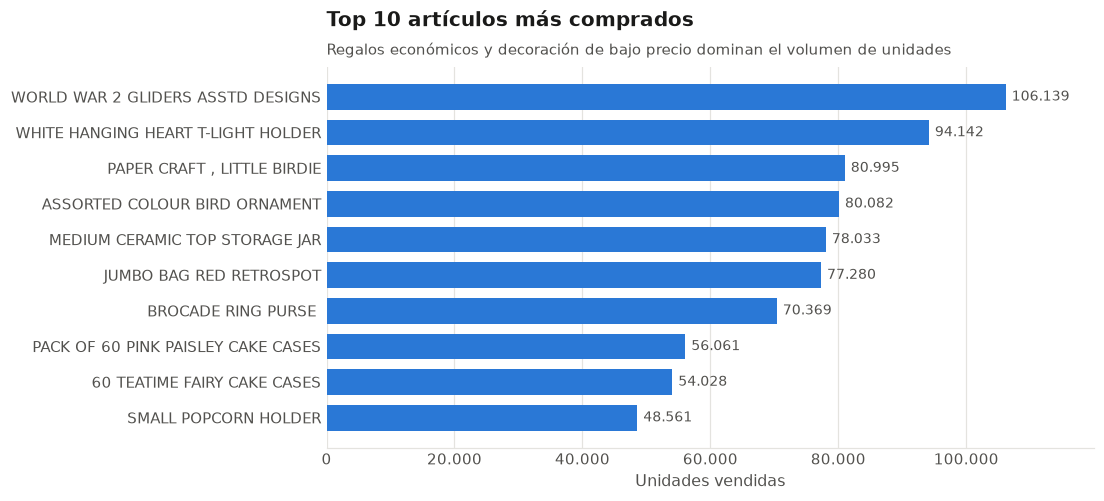

In [65]:
articulos = (df_sales.groupby(["stock_code", "description"], as_index=False)["quantity"]
             .sum().sort_values("quantity", ascending=False))

top_articulos = articulos.head(10).sort_values("quantity")

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.barh(top_articulos["description"], top_articulos["quantity"], color=AZUL, height=0.72)

estilo(ax, "x")
formato(ax, "x")
etiquetar_barras(ax)
ax.margins(x=0.13)

ax.set_xlabel("Unidades vendidas")
ax.set_ylabel("")
titulo(ax, "Top 10 artículos más comprados",
       "Regalos económicos y decoración de bajo precio dominan el volumen de unidades")

guardar(fig, "01_top10_articulos_comprados")
plt.show()

**Observación:** Con más de 100.000 unidades vendidas, el top 1 se tratan de aviones de la segunda guerra mundial armables de cartón. Siguiendo el grafico, el top 2 se trata de porta velas colgante blanco con forma de corazón. Y con el top 3 para finalizar se trata de un pack de armado de manualidades de papel de Little Birdie. Como podemos ver, lo que más se compra se trata de regalos para niños los cuales son realmente baratos y para esos tiempos (2009 a 2011) podías entretener a un niño/a con ellos.

### 4.1.2 ¿Cuáles son los artículos más caros y más baratos por unidad?

Ambos rankings responden a la misma pregunta —cómo se distribuye el precio del catálogo— así
que se muestran juntos: el contraste entre los dos extremos es el hallazgo.

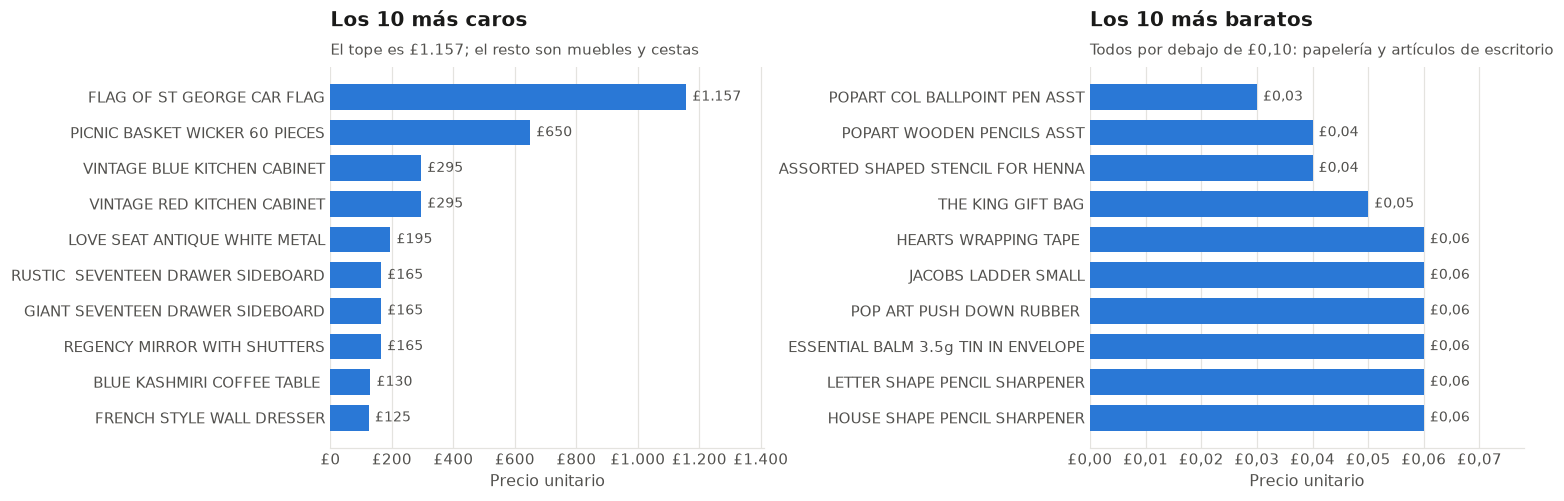

In [66]:
top_caros = (df_sales.groupby(["stock_code", "description"], as_index=False)["unit_price"]
             .max().sort_values("unit_price", ascending=False).head(10).sort_values("unit_price"))

# Para el ranking de más baratos se usa el precio mínimo al que se vendió cada artículo
top_baratos = (df_sales.groupby(["stock_code", "description"], as_index=False)["unit_price"]
               .min().sort_values("unit_price").head(10).sort_values("unit_price", ascending=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.barh(top_caros["description"], top_caros["unit_price"], color=AZUL, height=0.72)
estilo(ax1, "x")
formato(ax1, "x", moneda=True)
etiquetar_barras(ax1, fmt=lambda v: libras(v))
ax1.margins(x=0.22)
ax1.set_xlabel("Precio unitario")
titulo(ax1, "Los 10 más caros",
       f"El tope es {libras(top_caros['unit_price'].max())}; el resto son muebles y cestas")

ax2.barh(top_baratos["description"], top_baratos["unit_price"], color=AZUL, height=0.72)
estilo(ax2, "x")
formato(ax2, "x", moneda=True, dec=2)
etiquetar_barras(ax2, fmt=lambda v: libras(v, 2))
ax2.margins(x=0.30)
ax2.set_xlabel("Precio unitario")
titulo(ax2, "Los 10 más baratos", "Todos por debajo de £0,10: papelería y artículos de escritorio")

fig.subplots_adjust(wspace=0.75)

guardar(fig, "02_articulos_caros_baratos")
plt.show()

**Observación:** El catálogo cubre un rango enorme. En el extremo caro, una bandera de coche de
Inglaterra por casi £1.200 y un conjunto de cestas de mimbre; el resto del top 10 son muebles,
artículos voluminosos y de baja rotación. En el extremo barato, ningún artículo llega a £0,10:
son lápices, gomas, sacapuntas y bolsas de regalo, productos pensados para venderse por lotes.

### 4.1.3 Y hablando de costos y cantidades, ¿Es más probable que compren más cantidad si es más barato el producto en unidad?
Por un tema económico, parece ser obvio que sí, pero quiero ver qué tan fuerte es esa relación
entre lo barato y la cantidad comprada.

Correlación de Pearson (lineal):     -0.029
Correlación de Spearman (monótona):  -0.426


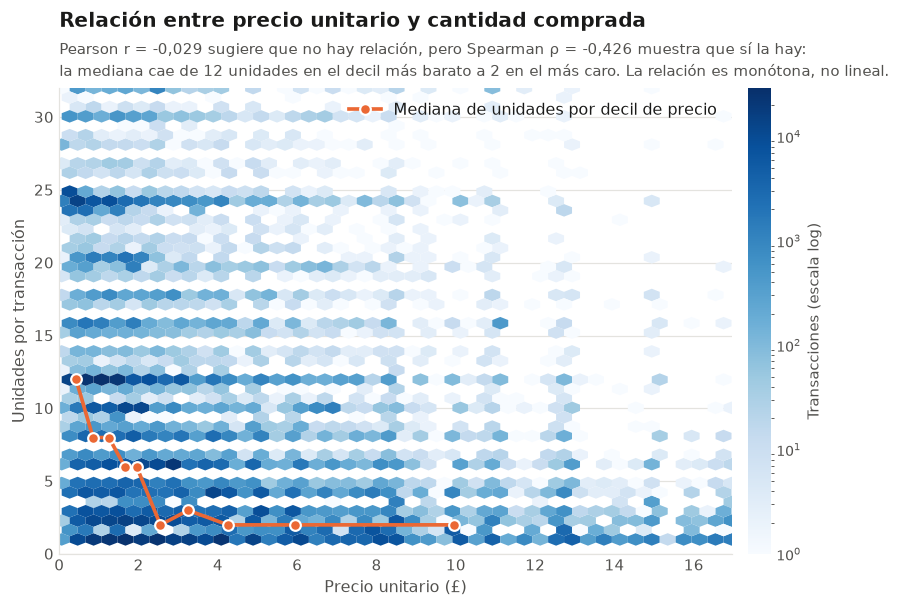

In [67]:
pearson = df_sales["unit_price"].corr(df_sales["quantity"])
spearman, _ = spearmanr(df_sales["unit_price"], df_sales["quantity"])

print(f"Correlación de Pearson (lineal):     {pearson:.3f}")
print(f"Correlación de Spearman (monótona):  {spearman:.3f}")

# Mediana de unidades compradas en cada decil de precio unitario
deciles = pd.qcut(df_sales["unit_price"], 10, duplicates="drop")
resumen = (df_sales.groupby(deciles, observed=True)
           .agg(precio=("unit_price", "median"), unidades=("quantity", "median"))
           .reset_index(drop=True))

# Se recorta la nube para que sea legible: el eje X al percentil 99 del precio
# y el eje Y al percentil 95 de la cantidad, donde ocurre casi toda la masa de datos.
x_max = df_sales["unit_price"].quantile(0.99)
y_max = df_sales["quantity"].quantile(0.95)
visible = df_sales[(df_sales["unit_price"] <= x_max) & (df_sales["quantity"] <= y_max)]

fig, ax = plt.subplots(figsize=(9.5, 5.5))

hb = ax.hexbin(visible["unit_price"], visible["quantity"], gridsize=42, bins="log",
               cmap="Blues", mincnt=1, linewidths=0)

dentro = resumen[resumen["precio"] <= x_max]
ax.plot(dentro["precio"], dentro["unidades"], color=NARANJA, linewidth=2.4,
        marker="o", markersize=7, markeredgecolor="white", markeredgewidth=1.4,
        label="Mediana de unidades por decil de precio", zorder=5)

barra = fig.colorbar(hb, ax=ax, pad=0.02)
barra.set_label("Transacciones (escala log)", color=TINTA_2, fontsize=9.5)
barra.outline.set_visible(False)
barra.ax.tick_params(length=0, labelsize=9)

ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)
estilo(ax, "y")
ax.set_xlabel("Precio unitario (£)")
ax.set_ylabel("Unidades por transacción")
ax.legend(loc="upper right")

titulo(ax, "Relación entre precio unitario y cantidad comprada",
       f"Pearson r = {num(pearson, 3)} sugiere que no hay relación, pero Spearman ρ = {num(spearman, 3)} muestra que sí la hay:\n"
       "la mediana cae de 12 unidades en el decil más barato a 2 en el más caro. La relación es monótona, no lineal.")

guardar(fig, "03_precio_vs_cantidad")
plt.show()

**Observación:** Este es el gráfico que más cambió de conclusión al mirarlo bien. La correlación
de Pearson es prácticamente nula (r = -0,029), y la lectura fácil sería "el precio no influye en
la cantidad". Pero Pearson solo mide relaciones **lineales**, y acá la relación no lo es: al
agrupar por deciles de precio, la mediana de unidades por transacción cae de 12 en el decil más
barato a 2 en el más caro, de forma sostenida. La correlación de Spearman, que mide relaciones
monótonas, da ρ = -0,426.

Es decir: sí se compra más cantidad cuando el artículo es más barato. Lo que no existe es una
relación proporcional, y por eso el coeficiente lineal no la detecta.

## 4.2 Facturas y Clientes

### 4.2.1 ¿Cuánto gasta el cliente en promedio por factura?
Enfocándonos más en las facturas del dataset, cual sería el gasto promedio por cada compra que realiza.

Gasto promedio por factura: £497,16
Gasto mediano por factura:  £301,23


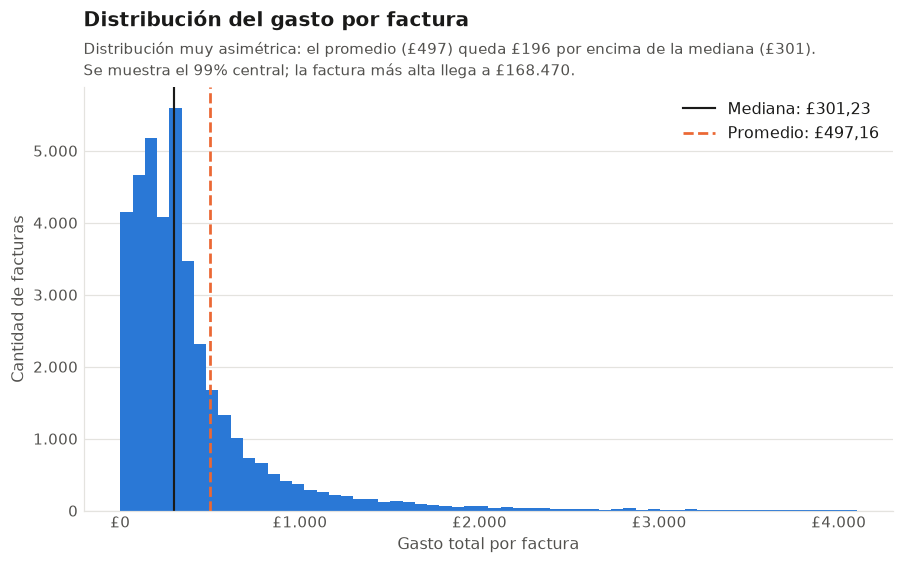

In [68]:
factura_precio_total = df_sales.groupby("invoice")["total_price"].sum()

promedio = factura_precio_total.mean()
mediana = factura_precio_total.median()
p99 = factura_precio_total.quantile(0.99)

print(f"Gasto promedio por factura: {libras(promedio, 2)}")
print(f"Gasto mediano por factura:  {libras(mediana, 2)}")

fig, ax = plt.subplots(figsize=(9.5, 5))

ax.hist(factura_precio_total[factura_precio_total <= p99], bins=60, color=AZUL)

ax.axvline(mediana, color=TINTA, linewidth=1.4, label=f"Mediana: {libras(mediana, 2)}")
ax.axvline(promedio, color=NARANJA, linewidth=1.8, linestyle="--",
           label=f"Promedio: {libras(promedio, 2)}")

estilo(ax, "y")
formato(ax, "x", moneda=True)
formato(ax, "y")

ax.set_xlabel("Gasto total por factura")
ax.set_ylabel("Cantidad de facturas")
ax.legend(loc="upper right")

titulo(ax, "Distribución del gasto por factura",
       f"Distribución muy asimétrica: el promedio ({libras(promedio)}) queda {libras(promedio - mediana)} por encima de la mediana ({libras(mediana)}).\n"
       f"Se muestra el 99% central; la factura más alta llega a {libras(factura_precio_total.max())}.")

guardar(fig, "04_dist_gasto_factura")
plt.show()

**Observación:** El gasto promedio por factura es de £497.16, que si lo pensáramos como si los compradores solo fueran clientes minoristas parecería mucho dinero, pero desde la descripción del dataset, se narra que hay una gran parte de compradores mayoristas los cuales ponen un peso en la balanza del gasto promedio.

Por otro lado, también decidí mostrar la mediana, la cual es de £301.23, notablemente menor comparado a los casi £500 del promedio, y en este dato es donde los clientes minoristas tienen un poco más de protagonismo, porque la mediana toma la posición central (50%) de los datos, haciendo que se tome más en cuenta la población de facturas de minoristas en los datos.

### 4.2.2 ¿Cuáles son las facturas más caras?

Un ranking de números de factura no aporta nada como gráfico —las etiquetas del eje no significan
nada para el lector—, así que se muestra como tabla.

In [69]:
facturas_caras = (df_sales.groupby("invoice", as_index=False)["total_price"]
                  .sum().sort_values("total_price", ascending=False).head(10))

facturas_caras["total_price"] = facturas_caras["total_price"].map(lambda v: libras(v, 2))
facturas_caras.columns = ["Factura", "Total facturado"]

facturas_caras.reset_index(drop=True)

,Factura,Total facturado
0,581483,"£168.469,60"
1,541431,"£77.183,60"
2,574941,"£52.940,94"
3,576365,"£50.653,91"
4,533027,"£49.844,99"
5,531516,"£45.332,97"
6,493819,"£44.051,60"
7,556444,"£38.970,00"
8,524181,"£33.167,80"
9,567423,"£31.698,16"


**Observación:** Hay una factura que resalta muy por encima del resto: la N° 581.483, por más de
£160.000 en una sola compra online.

Mi duda ya no es cuánto gastó, sino en qué...

In [70]:
top1 = df_sales[df_sales["invoice"] == "581483"]
print(top1[["description", "quantity", "unit_price", "total_price", "customer_id"]])

                         description  quantity  unit_price  total_price  \
1065882  PAPER CRAFT , LITTLE BIRDIE     80995        2.08     168469.6   

        customer_id  
1065882       16446  


¡Que interesante! Solo compro un tipo de artículo, paquetes de armado de papel de Little Birdie, por una cantidad de casi 81.000 unidades (!!) que le termino costando lo que vemos en la factura. Acabamos de identificar al principal culpable de que este articulo sea el top 3 más comprados (figura 4.1.1) del dataset. 

### 4.2.3 ¿Que clientes gastaron más?
Si bien no podemos identificar a los clientes (solo tenemos sus códigos ID), podemos saber quién gasto más en el periodo que contienen los datos.

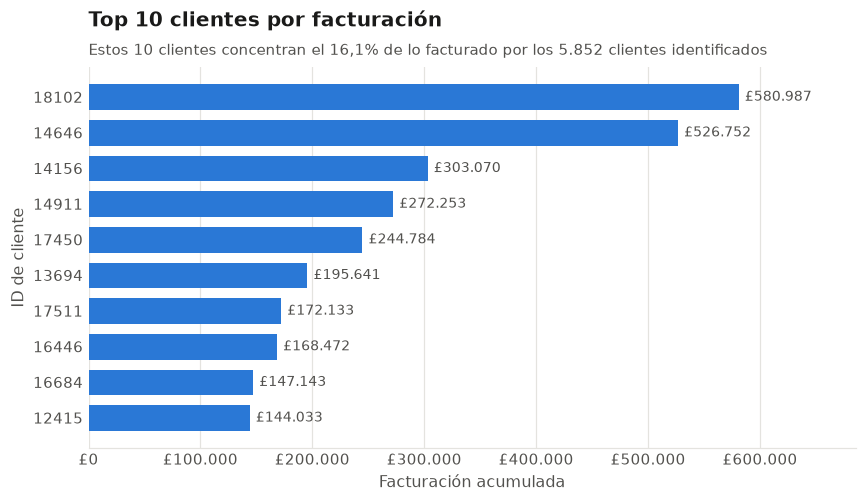

In [71]:
facturacion_clientes = (df_sales.dropna(subset=["customer_id"])
                        .groupby("customer_id")["total_price"].sum())

top_clientes = facturacion_clientes.sort_values(ascending=False).head(10).sort_values()
peso_top10 = top_clientes.sum() / facturacion_clientes.sum() * 100

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.barh(top_clientes.index.astype(str), top_clientes.values, color=AZUL, height=0.72)

estilo(ax, "x")
formato(ax, "x", moneda=True)
etiquetar_barras(ax, fmt=lambda v: libras(v))
ax.margins(x=0.18)

ax.set_xlabel("Facturación acumulada")
ax.set_ylabel("ID de cliente")
titulo(ax, "Top 10 clientes por facturación",
       f"Estos 10 clientes concentran el {pct(peso_top10)} de lo facturado por los "
       f"{num(len(facturacion_clientes))} clientes identificados")

guardar(fig, "05_top10_clientes")
plt.show()

**Observación:** Un detalle a destacar es que el top 8 (ID N° 16446) es el mismo cliente que tiene la factura más cara del dataset.

### 4.2.4 ¿Qué tan concentrada está la facturación en unos pocos clientes?

El top 10 muestra los casos extremos, pero no dice si el negocio depende de unos pocos clientes
o si la facturación está repartida. La curva de concentración (Pareto) responde eso.

258 clientes (4,4%) explican la mitad de la facturación
El 10% de los clientes explica el 63,9% de la facturación


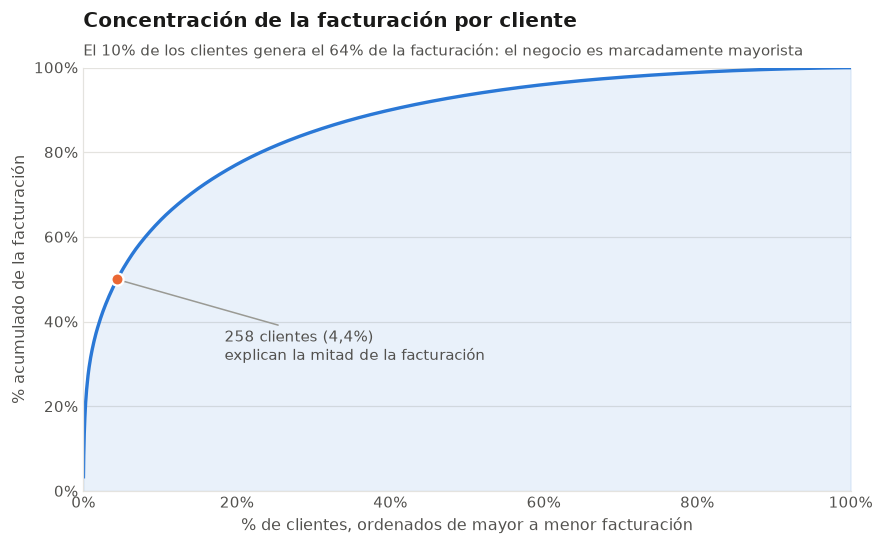

In [72]:
orden = facturacion_clientes.sort_values(ascending=False)
acumulado = (orden.cumsum() / orden.sum() * 100).values
pct_clientes = np.arange(1, len(orden) + 1) / len(orden) * 100

clientes_mitad = int((acumulado < 50).sum()) + 1
pct_mitad = clientes_mitad / len(orden) * 100
acum_top10 = acumulado[int(len(orden) * 0.10) - 1]

print(f"{clientes_mitad} clientes ({pct(pct_mitad)}) explican la mitad de la facturación")
print(f"El 10% de los clientes explica el {pct(acum_top10)} de la facturación")

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(pct_clientes, acumulado, color=AZUL, linewidth=2.2)
ax.fill_between(pct_clientes, acumulado, color=AZUL, alpha=0.10)

ax.plot([pct_mitad], [50], marker="o", markersize=8, color=NARANJA,
        markeredgecolor="white", markeredgewidth=1.5, zorder=5)
ax.annotate(f"{num(clientes_mitad)} clientes ({pct(pct_mitad)})\nexplican la mitad de la facturación",
            xy=(pct_mitad, 50), xytext=(pct_mitad + 14, 31), fontsize=9.5, color=TINTA_2,
            arrowprops=dict(arrowstyle="-", color=GRIS, linewidth=1))

estilo(ax, "y")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}%"))

ax.set_xlabel("% de clientes, ordenados de mayor a menor facturación")
ax.set_ylabel("% acumulado de la facturación")
titulo(ax, "Concentración de la facturación por cliente",
       f"El 10% de los clientes genera el {pct(acum_top10, 0)} de la facturación: el negocio es marcadamente mayorista")

guardar(fig, "06_pareto_clientes")
plt.show()

**Observación:** La concentración es fuerte: 258 clientes —el 4,4% de los 5.852 identificados—
explican la mitad de la facturación, y el 10% superior llega a casi dos tercios. Esto confirma con
números el perfil mayorista que ya insinuaban el promedio por factura y la factura extrema de
£160.000: no se trata de una tienda minorista con muchos compradores chicos, sino de un negocio
sostenido por un núcleo reducido de revendedores.

## 4.3 Fechas y Horas

### 4.3.1 ¿Existe un aumento de la cantidad de compras por año?
En este caso vamos a tener en cuenta solo los años 2010 y 2011, ya que, en este dataset, el 2009 solo contiene las transacciones del mes de diciembre, por lo cual haría la comparación dispareja respecto a los otros 2 años.

Facturas ene-nov 2010: 18.077
Facturas ene-nov 2011: 17.407
Variación interanual: -3,71%


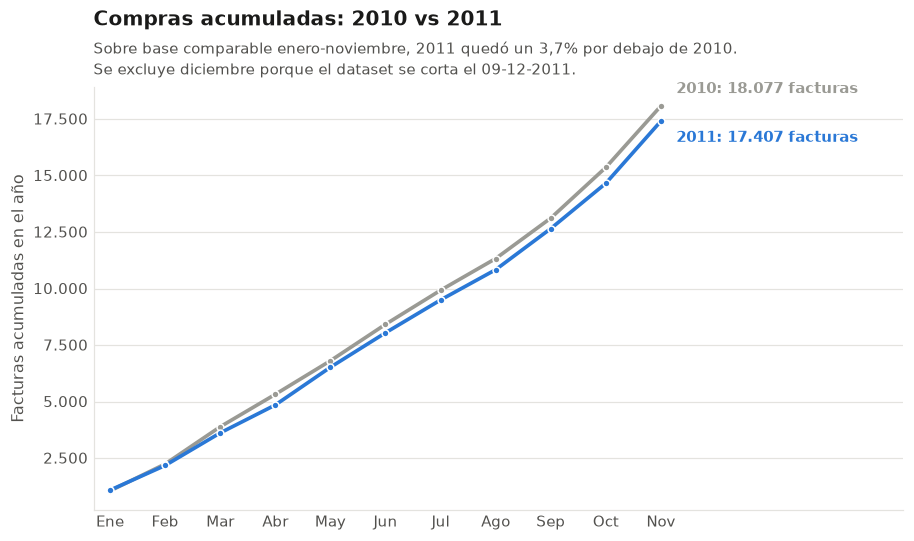

In [73]:
compras_mes = (df_sales[df_sales["year"].isin([2010, 2011])]
               .groupby(["year", "month"], as_index=False)["invoice"].nunique())

compras_mes["acumulado"] = compras_mes.groupby("year")["invoice"].cumsum()

# El dataset termina el 09-12-2011, así que diciembre de 2011 está incompleto.
# La comparación interanual se hace sobre enero-noviembre, que sí es una base comparable.
comparable = compras_mes[compras_mes["month"] <= 11]
total_2010 = comparable.loc[comparable["year"] == 2010, "invoice"].sum()
total_2011 = comparable.loc[comparable["year"] == 2011, "invoice"].sum()
variacion = (total_2011 / total_2010 - 1) * 100

print(f"Facturas ene-nov 2010: {num(total_2010)}")
print(f"Facturas ene-nov 2011: {num(total_2011)}")
print(f"Variación interanual: {pct(variacion, 2)}")

fig, ax = plt.subplots(figsize=(9.5, 5))

for anio, color, desplazamiento in [(2010, GRIS, 11), (2011, AZUL, -11)]:
    datos = comparable[comparable["year"] == anio]
    ax.plot(datos["month"], datos["acumulado"], color=color, linewidth=2.4,
            marker="o", markersize=4.5, markeredgecolor="white", markeredgewidth=1)
    ax.annotate(f"{anio}: {num(datos['acumulado'].iloc[-1])} facturas",
                xy=(11, datos["acumulado"].iloc[-1]), xytext=(10, desplazamiento),
                textcoords="offset points", color=color, fontsize=10,
                fontweight="bold", va="center")

estilo(ax, "y")
formato(ax, "y")
ax.set_xticks(range(1, 12), MESES[:11])
ax.set_xlim(0.7, 15.4)

ax.set_xlabel("")
ax.set_ylabel("Facturas acumuladas en el año")
titulo(ax, "Compras acumuladas: 2010 vs 2011",
       f"Sobre base comparable enero-noviembre, 2011 quedó un {pct(abs(variacion))} por debajo de 2010.\n"
       "Se excluye diciembre porque el dataset se corta el 09-12-2011.")

guardar(fig, "07_compras_acumuladas_2010_2011")
plt.show()

**Observación:** Acá apareció un problema de medición. Comparando los años completos, 2011 cae un
7,15% respecto de 2010; pero el dataset se corta el **9 de diciembre de 2011**, así que ese
diciembre tiene apenas nueve días (816 facturas contra 1.550 en diciembre de 2010). Buena parte de
la "caída" era, en realidad, un mes truncado.

Sobre una base comparable (enero a noviembre de cada año), la caída real es del **3,71%**. La
tendencia negativa existe y sigue contradiciendo la expectativa de crecimiento del comercio online
en ese período, pero es la mitad de pronunciada de lo que sugería la comparación ingenua.

### 4.3.2 ¿En qué meses del año se compra más?
Al tratarse del mercado online de regalaría, uno ya asume en qué periodo se dan más compras de lo normal.

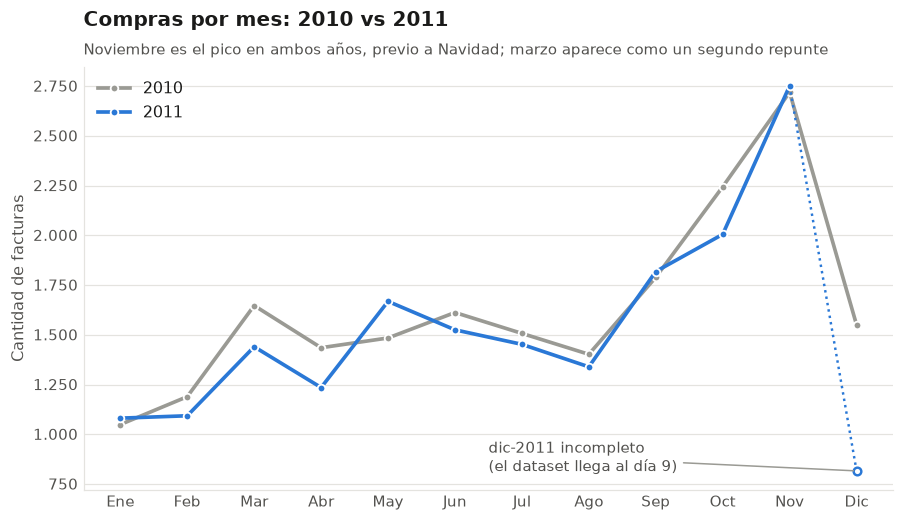

In [74]:
compras_por_mes = (df_sales[df_sales["year"].isin([2010, 2011])]
                   .groupby(["year", "month"], as_index=False)["invoice"].nunique())

fig, ax = plt.subplots(figsize=(9.5, 5))

for anio, color in [(2010, GRIS), (2011, AZUL)]:
    datos = compras_por_mes[compras_por_mes["year"] == anio].reset_index(drop=True)
    if anio == 2011:
        # Diciembre de 2011 está incompleto: se dibuja punteado y con marcador hueco
        ax.plot(datos["month"][:11], datos["invoice"][:11], color=color, linewidth=2.4,
                marker="o", markersize=5, markeredgecolor="white", markeredgewidth=1.2,
                label=str(anio))
        ax.plot(datos["month"][10:], datos["invoice"][10:], color=color,
                linewidth=1.6, linestyle=":")
        ax.plot(12, datos["invoice"].iloc[11], marker="o", markersize=5,
                markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.6)
        ax.annotate("dic-2011 incompleto\n(el dataset llega al día 9)",
                    xy=(12, datos["invoice"].iloc[11]), xytext=(0.50, 0.045),
                    textcoords="axes fraction", fontsize=9.5, color=TINTA_2,
                    arrowprops=dict(arrowstyle="-", color=GRIS, linewidth=1))
    else:
        ax.plot(datos["month"], datos["invoice"], color=color, linewidth=2.4,
                marker="o", markersize=5, markeredgecolor="white", markeredgewidth=1.2,
                label=str(anio))

estilo(ax, "y")
formato(ax, "y")
ax.set_xticks(range(1, 13), MESES)
ax.set_xlabel("")
ax.set_ylabel("Cantidad de facturas")
ax.legend(loc="upper left")

titulo(ax, "Compras por mes: 2010 vs 2011",
       "Noviembre es el pico en ambos años, previo a Navidad; marzo aparece como un segundo repunte")

guardar(fig, "08_compras_por_mes")
plt.show()

**Observación:** Como suponía, el mayor pico de compras mensuales se da en noviembre, previo a navidad y año nuevo. 

Otro pico a tener en cuenta es marzo, esto se produce porque la pascua en 2010 y 2011, se festejaron el 4 de abril y 24 de abril respectivamente, mes posterior al pico de compras de regalaría.

### 4.3.3 ¿Cómo evolucionó la facturación mes a mes?

Las preguntas anteriores cuentan *cantidad* de compras. Esta mira el dinero, que es lo que
finalmente le importa al negocio: puede haber menos facturas pero de mayor valor.

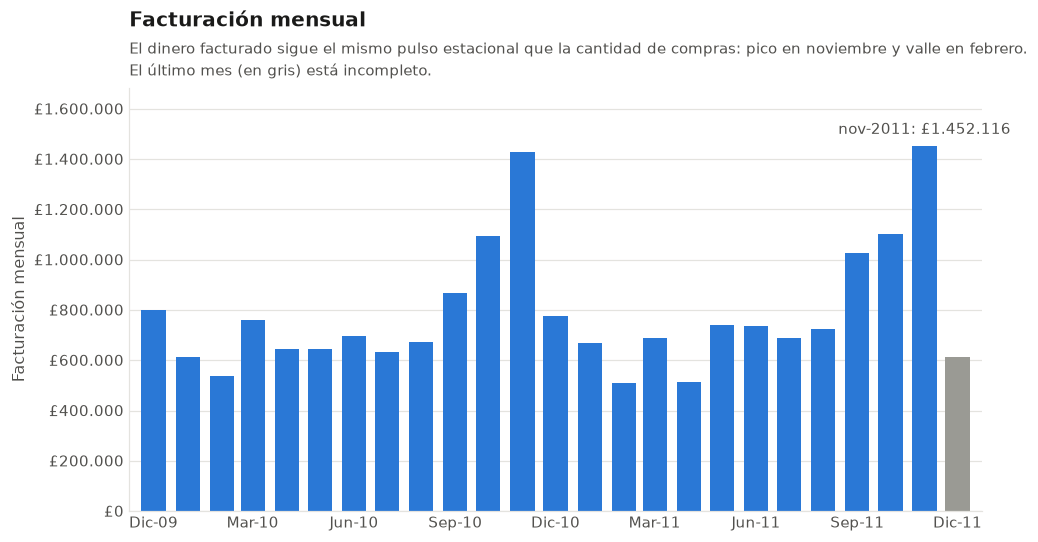

In [75]:
facturacion_mensual = (df_sales.groupby(df_sales["invoice_datetime"].dt.to_period("M"))["total_price"]
                       .sum().reset_index())

facturacion_mensual["periodo"] = facturacion_mensual["invoice_datetime"].dt.to_timestamp()

# El último mes está incompleto (el dataset termina el 09-12-2011)
incompleto = facturacion_mensual["invoice_datetime"].iloc[-1]
colores = [GRIS if p == incompleto else AZUL for p in facturacion_mensual["invoice_datetime"]]

pico = facturacion_mensual.loc[facturacion_mensual["total_price"].idxmax()]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(facturacion_mensual["periodo"], facturacion_mensual["total_price"],
       color=colores, width=22)

ax.annotate(f"nov-2011: {libras(pico['total_price'])}",
            xy=(pico["periodo"], pico["total_price"]), xytext=(0, 8),
            textcoords="offset points", ha="center", fontsize=9.5, color=TINTA_2)

estilo(ax, "y")
formato(ax, "y", moneda=True)

etiquetas = facturacion_mensual["periodo"][::3]
ax.set_xticks(etiquetas, [f"{MESES[t.month - 1]}-{t.year % 100:02d}" for t in etiquetas])
ax.set_xlim(facturacion_mensual["periodo"].iloc[0] - pd.Timedelta(days=22),
            facturacion_mensual["periodo"].iloc[-1] + pd.Timedelta(days=22))

ax.set_xlabel("")
ax.set_ylabel("Facturación mensual")
ax.margins(y=0.16)

titulo(ax, "Facturación mensual",
       "El dinero facturado sigue el mismo pulso estacional que la cantidad de compras: pico en noviembre y valle en febrero.\n"
       "El último mes (en gris) está incompleto.")

guardar(fig, "09_facturacion_mensual")
plt.show()

**Observación:** La facturación sigue el mismo pulso estacional que la cantidad de compras —pico
en noviembre (£1,45 M en 2011), valle en febrero— y ambos años terminan en niveles muy parecidos.
Esto refuerza la lectura del apartado anterior: la caída interanual en cantidad de facturas no se
tradujo en una caída equivalente de ingresos, porque el ticket promedio se sostuvo.

### 4.3.4 ¿A qué hora del día se dan más compras?

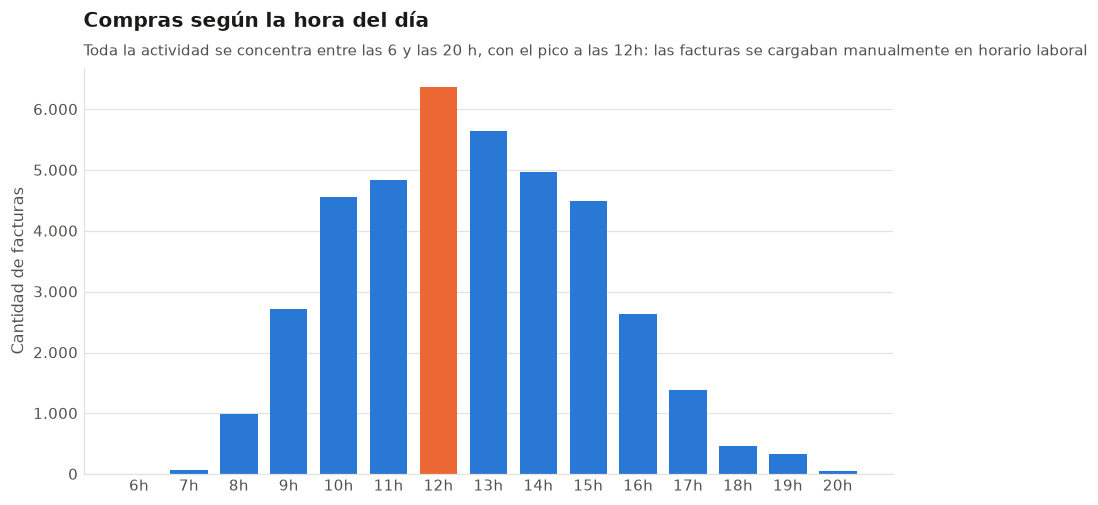

In [76]:
compras_por_hora = (df_sales.assign(hora=df_sales["invoice_datetime"].dt.hour)
                    .groupby("hora", as_index=False)["invoice"].nunique())

hora_pico = compras_por_hora.loc[compras_por_hora["invoice"].idxmax(), "hora"]
colores = [NARANJA if h == hora_pico else AZUL for h in compras_por_hora["hora"]]

fig, ax = plt.subplots(figsize=(9.5, 4.8))

ax.bar(compras_por_hora["hora"], compras_por_hora["invoice"], color=colores, width=0.75)

estilo(ax, "y")
formato(ax, "y")
ax.set_xticks(compras_por_hora["hora"], [f"{h}h" for h in compras_por_hora["hora"]])
ax.set_xlabel("")
ax.set_ylabel("Cantidad de facturas")

titulo(ax, "Compras según la hora del día",
       f"Toda la actividad se concentra entre las 6 y las 20 h, con el pico a las {hora_pico}h: "
       "las facturas se cargaban manualmente en horario laboral")

guardar(fig, "10_compras_por_hora")
plt.show()

**Observación:** La mayor cantidad de compras se dan alrededor del mediodía, aunque como podemos ver, las horas de la facturas están dentro de un rango horario desde las 6hs hasta las 20hs, y esto se debe que en esos años las facturas eran cargadas por personas, en su horario de empleo, el cual se encuentra distribuido como en el gráfico. Por lo tanto, las compras que eran realizadas fuera de su horario, se cargaba al día siguiente.

## 4.4 Paises

### 4.4.1 ¿De dónde provienen los clientes?

El Reino Unido concentra la enorme mayoría de los clientes, hasta el punto de que incluirlo en el
gráfico deja al resto de los países como barras invisibles. Por eso se lo excluye del gráfico y se
lo reporta como cifra en el subtítulo.

Clientes en el Reino Unido: 5.334
Clientes extranjeros: 530 (9,0% del total)
Facturación extranjera: 14,5% del total


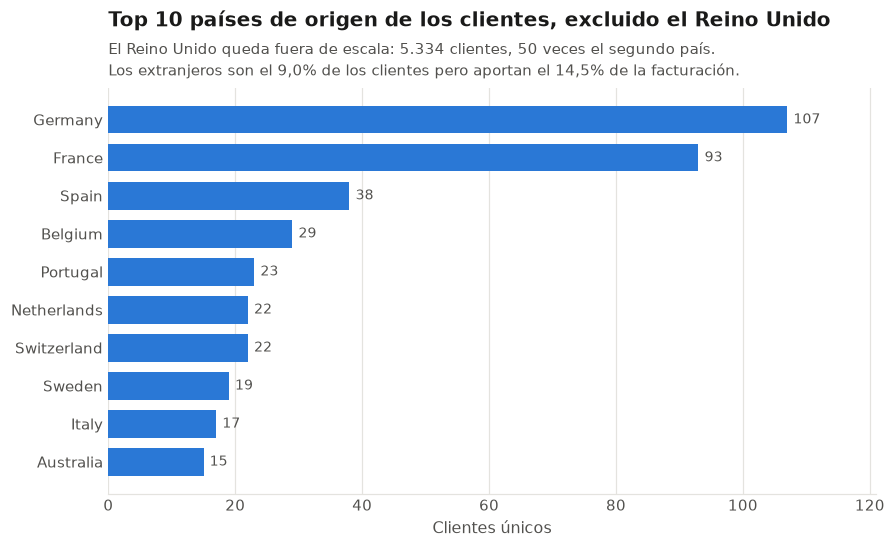

In [77]:
clientes_pais = (df_sales.dropna(subset=["customer_id"])
                 .groupby("country")["customer_id"].nunique().sort_values(ascending=False))

facturacion_pais = df_sales.groupby("country")["total_price"].sum()

uk_clientes = clientes_pais["United Kingdom"]
resto = clientes_pais.drop("United Kingdom")

pct_ext_clientes = resto.sum() / clientes_pais.sum() * 100
pct_ext_facturacion = (facturacion_pais.drop("United Kingdom").sum()
                       / facturacion_pais.sum() * 100)

print(f"Clientes en el Reino Unido: {num(uk_clientes)}")
print(f"Clientes extranjeros: {num(resto.sum())} ({pct(pct_ext_clientes)} del total)")
print(f"Facturación extranjera: {pct(pct_ext_facturacion)} del total")

top_paises = resto.head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.barh(top_paises.index, top_paises.values, color=AZUL, height=0.72)

estilo(ax, "x")
formato(ax, "x")
etiquetar_barras(ax)
ax.margins(x=0.13)

ax.set_xlabel("Clientes únicos")
ax.set_ylabel("")
titulo(ax, "Top 10 países de origen de los clientes, excluido el Reino Unido",
       f"El Reino Unido queda fuera de escala: {num(uk_clientes)} clientes, {uk_clientes / resto.iloc[0]:.0f} veces el segundo país.\n"
       f"Los extranjeros son el {pct(pct_ext_clientes)} de los clientes pero aportan el {pct(pct_ext_facturacion)} de la facturación.")

guardar(fig, "11_top10_paises")
plt.show()

**Observación:** La dependencia del mercado local es casi total: 5.334 clientes únicos en el
Reino Unido contra 530 en todo el resto del mundo. Los extranjeros son solo el 9,0% de los clientes, pero
aportan el 14,5% de la facturación —o sea que, en promedio, compran más por cliente que los
británicos—. Alemania y Francia encabezan el mercado externo, y salvo Australia el top 10 es
íntegramente europeo, consistente con costos de envío bajos dentro del continente.

## 4.5 Extras

### 4.5.1 Matriz de Correlación

Una aclaración necesaria: `total_price` se calculó como `quantity × unit_price`, así que su
correlación alta con `quantity` (0,86) es una consecuencia de la definición, no un hallazgo. Se la
deja en la matriz para dejar explícito ese punto.

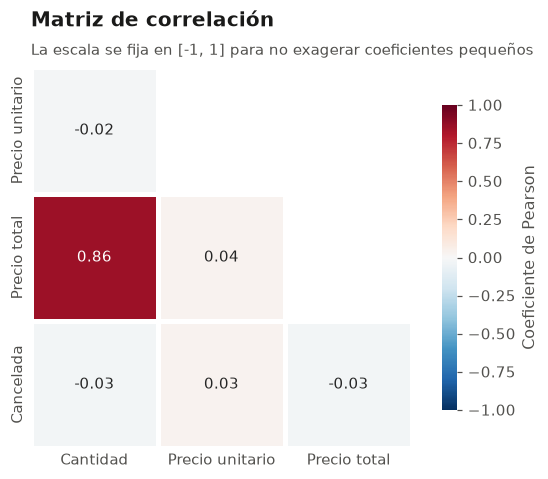

In [78]:
df_corr = df_products[["quantity", "unit_price", "total_price", "canceled"]].copy()
df_corr["canceled"] = df_corr["canceled"].astype(int)
df_corr.columns = ["Cantidad", "Precio unitario", "Precio total", "Cancelada"]

# Se recortan la primera fila y la última columna, que quedarían vacías al
# enmascarar el triángulo superior.
corr = df_corr.corr().iloc[1:, :-1]
mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.heatmap(corr, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, linewidths=2, linecolor="white", square=True,
            annot_kws={"fontsize": 10}, cbar_kws={"shrink": 0.8, "label": "Coeficiente de Pearson"},
            ax=ax)

ax.tick_params(length=0)
titulo(ax, "Matriz de correlación",
       "La escala se fija en [-1, 1] para no exagerar coeficientes pequeños")

guardar(fig, "12_matriz_correlacion")
plt.show()

**Observación:** Fuera de la relación definicional entre cantidad y precio total, no hay
correlaciones lineales relevantes entre las variables numéricas: todas quedan por debajo de |0,04|.
El caso de precio y cantidad ya se analizó en el apartado 4.1.3, donde se vio que la relación
existe pero es monótona y no lineal, y por lo tanto invisible para esta matriz.

### 4.5.2 Hipotesis: ¿Las facturas de mayor valor tienen una mayor probabilidad de ser canceladas?
Hipótesis nula — H₀: El valor total de una factura no está relacionado con que esta sea cancelada.

Hipótesis alternativa — H₁: Las facturas canceladas presentan un valor total diferente al de las facturas no canceladas.

**Nota:** en las facturas canceladas, quantity es negativo (representan devoluciones), por lo que total_price (quantity * unit_price) también resulta negativo. Comparar total_price tal cual sesgaría la prueba, ya que las canceladas siempre aparecerían con "menor valor" únicamente por el signo, y no porque la operación en sí sea de menor magnitud. Para comparar la magnitud real de las facturas entre ambos grupos, se utiliza el valor absoluto de total_price.


Antes de graficar, se calcula una sola vez la tabla de facturas con su valor y su estado, que
usan los tres análisis siguientes.

In [79]:
# Valor de cada factura junto con su estado. Se toma el valor absoluto porque las
# cancelaciones se registran con cantidades negativas, y se excluyen las facturas
# que netean exactamente cero para poder usar escala logarítmica más adelante.
totales_facturas = (df.groupby(["invoice", "canceled"])["total_price"]
                    .sum().abs().reset_index())
totales_facturas = totales_facturas[totales_facturas["total_price"] > 0]

resumen_estado = (totales_facturas.groupby("canceled")["total_price"]
                  .agg(facturas="count", mediana="median", promedio="mean").round(2))

print(resumen_estado)

          facturas  mediana  promedio
canceled                             
False        40082   302.24    514.82
True          8292    17.00    176.41


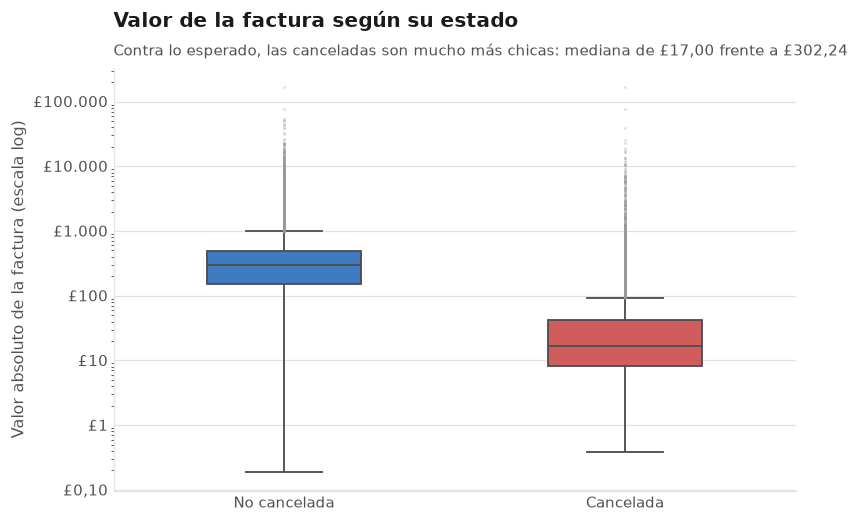

In [80]:
mediana_no = totales_facturas.loc[~totales_facturas["canceled"], "total_price"].median()
mediana_si = totales_facturas.loc[totales_facturas["canceled"], "total_price"].median()

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=totales_facturas, x="canceled", y="total_price", hue="canceled",
            palette={False: AZUL, True: ROJO}, legend=False, width=0.45, linewidth=1.2,
            flierprops=dict(marker="o", markersize=2, markerfacecolor=GRIS,
                            markeredgecolor="none", alpha=0.25),
            ax=ax)

ax.set_yscale("log")
estilo(ax, "y")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: libras(v, 0 if v >= 1 else 2)))
ax.set_xticks([0, 1], ["No cancelada", "Cancelada"])
ax.set_xlabel("")
ax.set_ylabel("Valor absoluto de la factura (escala log)")

titulo(ax, "Valor de la factura según su estado",
       f"Contra lo esperado, las canceladas son mucho más chicas: mediana de {libras(mediana_si, 2)} "
       f"frente a {libras(mediana_no, 2)}")

guardar(fig, "13_factura_por_estado")
plt.show()

### Mediana con intervalo bootstrap del 95%

El boxplot muestra la forma de ambas distribuciones; este gráfico estima cuánto vale la mediana de
cada grupo y con qué margen de error. Se usa la mediana y no el promedio porque, como se vio en el
apartado 4.2.1, la distribución del valor de las facturas tiene una cola muy larga que arrastra la
media.

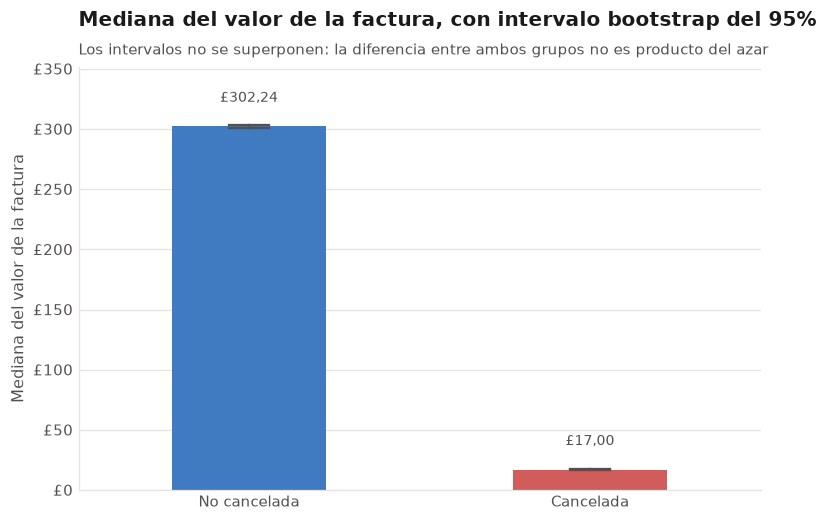

In [81]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(data=totales_facturas, x="canceled", y="total_price", hue="canceled",
            palette={False: AZUL, True: ROJO}, legend=False,
            estimator=np.median, errorbar=("ci", 95), n_boot=1000, seed=42,
            width=0.45, capsize=0.12, err_kws={"linewidth": 1.5, "color": TINTA_2}, ax=ax)

estilo(ax, "y")
formato(ax, "y", moneda=True)
etiquetar_barras(ax, fmt=lambda v: libras(v, 2), pad=14)
ax.margins(y=0.16)
ax.set_xticks([0, 1], ["No cancelada", "Cancelada"])
ax.set_xlabel("")
ax.set_ylabel("Mediana del valor de la factura")

titulo(ax, "Mediana del valor de la factura, con intervalo bootstrap del 95%",
       "Los intervalos no se superponen: la diferencia entre ambos grupos no es producto del azar")

guardar(fig, "14_mediana_factura_bootstrap")
plt.show()

### Prueba estadística: Mann–Whitney U

In [82]:
no_canceladas = totales_facturas.loc[~totales_facturas["canceled"], "total_price"]
canceladas = totales_facturas.loc[totales_facturas["canceled"], "total_price"]

stat, p_value = mannwhitneyu(no_canceladas, canceladas, alternative="two-sided")

print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Se rechaza H₀: existe una diferencia estadísticamente significativa entre el valor de las facturas canceladas y no canceladas.")
else:
    print("No se rechaza H₀: no hay evidencia suficiente de una diferencia estadísticamente significativa.")

Estadístico U: 295933459.00
Valor p: 0.0000
Se rechaza H₀: existe una diferencia estadísticamente significativa entre el valor de las facturas canceladas y no canceladas.


**Observación:** La hipótesis se confirma como diferencia, pero en el sentido contrario al
esperado. Las facturas canceladas no son las más caras: son marcadamente **más chicas**, con una
mediana de £17,00 frente a £302,24 de las no canceladas. La prueba de Mann–Whitney confirma que
la diferencia es estadísticamente significativa (p < 0,05).

La lectura de negocio es distinta a la que se planteaba al principio: las cancelaciones no
responden a clientes arrepentidos de una compra grande, sino a devoluciones puntuales de uno o
dos artículos —el patrón típico de un producto que llegó fallado o equivocado—.

# 5. Hallazgos Claves

1. **Los regalos económicos dominan las ventas.** Los tres artículos más vendidos (aviones de
   cartón de la Segunda Guerra Mundial, porta velas colgantes con forma de corazón y un pack de
   manualidades de papel) son productos baratos, lo que confirma el perfil de "regalería" del
   negocio.
2. **El catálogo cubre un rango de precio enorme**, desde £0,03 en papelería hasta £1.157 en una
   bandera de coche; los artículos caros son muebles y objetos voluminosos, de baja rotación.
3. **Sí se compra más cantidad cuando el artículo es más barato, pero la relación no es lineal.**
   La correlación de Pearson es casi nula (r = -0,029) y llevaría a descartar la relación; la de
   Spearman, que mide relaciones monótonas, da ρ = -0,426. Por deciles de precio, la mediana de
   unidades cae de 12 a 2.
4. **El gasto promedio por factura es de £497,16, pero la mediana es de solo £301,23**, lo que
   confirma la presencia de clientes mayoristas que elevan fuertemente el promedio.
5. **Existe una factura extrema que distorsiona varios análisis:** la N° 581.483, por más de
   £160.000, correspondiente a casi 81.000 unidades de un solo artículo, lo que explica por qué
   ese producto aparece en el top 3 de más vendidos.
6. **La facturación está muy concentrada:** 258 clientes (el 4,4% de los identificados) explican
   la mitad de los ingresos, y el 10% superior llega al 64%. El negocio se sostiene sobre un
   núcleo reducido de revendedores.
7. **La cantidad de compras cayó un 3,71% de 2010 a 2011**, medido sobre una base comparable de
   enero a noviembre. La comparación de años completos sugería un 7,15%, pero ese número estaba
   distorsionado por un diciembre de 2011 truncado al día 9.
8. **La facturación, en cambio, se sostuvo:** ambos años cierran en niveles similares, lo que
   indica que la caída en cantidad de facturas se compensó con un ticket promedio estable.
9. **Noviembre es, por lejos, el mes con más compras**, previo a Navidad y Año Nuevo; marzo
   aparece como un segundo pico asociado a la Pascua de esos años.
10. **Las facturas se concentran entre las 6 y las 20 horas, con pico al mediodía**, reflejo de
    que eran cargadas manualmente por empleados durante su horario laboral.
11. **El negocio depende fuertemente del Reino Unido:** los extranjeros son apenas el 9,0% de los
    clientes, aunque aportan el 14,5% de la facturación, es decir que gastan más por cliente.
12. **Las facturas canceladas son mucho más chicas, no más grandes.** Su mediana es de £17,00
    frente a £302,24 de las no canceladas, y la prueba de Mann–Whitney confirma que la diferencia
    es estadísticamente significativa (p < 0,05). Las cancelaciones responden a devoluciones
    puntuales, no a arrepentimientos sobre compras grandes.

# 6. Conclusiones
Este proyecto me permitió recorrer el proceso completo de un análisis de datos real, desde la carga de un dataset con más de un millón de filas hasta la comunicación de hallazgos concretos. Trabajar con un dataset con datos faltantes, duplicados, códigos no comerciales y valores inconsistentes en cantidad y precio me obligó a tomar decisiones de limpieza justificadas en cada paso, en lugar de aplicar reglas automáticas, y creo que el resultado es un análisis que refleja bastante bien la realidad de una tienda de regalería online con una fuerte componente mayorista. En general, quedé conforme con el proyecto: pude combinar limpieza y formateo de datos, EDA con preguntas de negocio concretas, visualizaciones variadas y, en la última sección, un contraste estadístico formal en lugar de quedarme solo con la lectura visual de un gráfico.

Dos hallazgos me dejaron una lección metodológica que me parece más valiosa que los números en sí. El primero es la relación entre precio y cantidad: mirando solo la correlación de Pearson habría concluido que no existe, cuando en realidad existe y es clara, pero monótona en vez de lineal. El segundo es la caída interanual: comparar 2010 contra 2011 sin notar que el dataset se corta el 9 de diciembre duplicaba el tamaño real de la caída. En ambos casos, el resultado inicial no era falso por un error de código, sino por no haber cuestionado qué estaba midiendo la métrica elegida.

Al mismo tiempo, noté algunas faltas en el dataset que limitan qué tan profundo puede llegar a ser el análisis. No hay ninguna variable que indique el motivo de una cancelación o devolución, lo que impide distinguir, por ejemplo, un error de carga de una insatisfacción real del cliente. Tampoco existen datos demográficos ni de segmentación de clientes (más allá del país), así que no se puede saber si el comportamiento de compra cambia según el tipo de cliente más allá de la distinción entre minorista y mayorista que se infiere indirectamente por el monto de la factura. Además, el dataset abarca poco más de dos años completos, lo cual es insuficiente para analizar tendencias de largo plazo o estacionalidad de manera robusta, y no incluye información de costos, por lo que no se puede calcular margen ni rentabilidad, solo facturación.

De cara a los próximos pasos, me gustaría profundizar el análisis de clientes mediante una segmentación tipo RFM (recencia, frecuencia, monto) para identificar distintos perfiles de compradores y detectar clientes en riesgo de abandono. También quiero explorar un análisis de canasta de mercado (market basket analysis) para ver qué productos se compran juntos, y armar un modelo simple de series de tiempo para las ventas mensuales que permita proyectar la demanda de los próximos meses. Por último, me interesa incorporar herramientas de visualización interactiva (como Dashboards en Power BI o Tableau) para que este análisis pueda navegarse dinámicamente en lugar de quedar fijo en un notebook.